## 1. Environment Setup & Data Loading

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# Add project root to sys.path to import modular pipeline
sys.path.append(os.path.abspath("../"))
from src.feature_engineering import load_data, run_feature_engineering_pipeline, prepare_datasets

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, 
                             median_absolute_error, mean_absolute_percentage_error)

sns.set_theme(style="whitegrid")
%matplotlib inline

In [60]:
# Run the feature engineering pipeline
data_path = "../data/cleaned_laptop_data.csv"
df_raw = load_data(data_path)
df_features = run_feature_engineering_pipeline(df_raw)

# Some values (like invalid Inches) may result in NaNs during calculations like PPI.
print(f"Rows before dropping NaNs: {len(df_features)}")
df_features = df_features.dropna()
print(f"Rows after dropping NaNs: {len(df_features)}")

# Split and Scale
X_train, X_test, y_train, y_test, scaler = prepare_datasets(df_features)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Rows before dropping NaNs: 1174
Rows after dropping NaNs: 1173
Training set: (938, 48)
Testing set: (235, 48)


/Users/nishkashah/Documents/laptop-price/src/feature_engineering.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.82720133  1.40725468 -0.08238266 -0.08238266 -0.08238266 -0.08238266
 -0.08238266 -0.82720133 -0.08238266 -0.08238266 -0.82720133 -0.82720133
 -0.08238266  1.40725468 -0.08238266 -0.82720133  1.40725468  1.40725468
 -0.82720133 -0.82720133 -0.08238266  1.40725468 -0.82720133 -0.08238266
  1.40725468 -0.08238266  1.40725468 -0.82720133  1.40725468 -0.08238266
 -0.82720133 -0.82720133 -0.08238266 -0.08238266 -0.82720133  4.38652935
 -0.08238266 -0.82720133 -0.08238266  1.40725468 -0.82720133 -0.08238266
 -0.08238266 -0.08238266 -0.08238266 -0.08238266 -0.82720133  1.40725468
 -0.08238266 -0.82720133 10.3450787  -0.08238266 -0.08238266 -0.08238266
  1.40725468 -0.08238266 -0.08238266 -0.08238266 -1.19961067 -0.08238266
 -0.82720133 -0.82720133 -0.08238266 -0.82720133 -0.08238266 -0.82720133
 -0.08

## 2. Model Training & Comparison

In [61]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf'),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

def evaluate_models(models, X_train, X_test, y_train, y_test):
    results = []
    for name, model in models.items():
        start_time = time()
        model.fit(X_train, y_train)
        train_time = time() - start_time
        y_pred = model.predict(X_test)
        
        # Metrics on Log Price
        mse_log = mean_squared_error(y_test, y_pred)
        rmse_log = np.sqrt(mse_log)
        mae_log = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        # Adjusted R2
        n = X_test.shape[0]
        p = X_test.shape[1]
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        
        medae_log = median_absolute_error(y_test, y_pred)
        mape_log = mean_absolute_percentage_error(y_test, y_pred)
        
        # Metrics on Original Price (Exp)
        y_test_exp = np.exp(y_test)
        y_pred_exp = np.exp(y_pred)
        mae_price = mean_absolute_error(y_test_exp, y_pred_exp)
        rmse_price = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
        mape_price = mean_absolute_percentage_error(y_test_exp, y_pred_exp)
        
        results.append({
            "Model": name,
            "R2 Score": r2,
            "Adj R2": adj_r2,
            "MSE (Log)": mse_log,
            "RMSE (Log)": rmse_log,
            "MAE (Log)": mae_log,
            "MedAE (Log)": medae_log,
            "MAPE (Log)": mape_log,
            "MAE (Price)": mae_price,
            "RMSE (Price)": rmse_price,
            "MAPE (Price)": mape_price,
            "Time (s)": train_time
        })
        
    return pd.DataFrame(results)

results_df = evaluate_models(models, X_train, X_test, y_train, y_test)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

# Save results for consistency
import os
os.makedirs("../results", exist_ok=True)
results_df.to_csv("../results/model_performance.csv", index=False)

results_df

,Model,R2 Score,Adj R2,MSE (Log),RMSE (Log),MAE (Log),MedAE (Log),MAPE (Log),MAE (Price),RMSE (Price),MAPE (Price),Time (s)
8,XGBoost,0.891420,0.863399,0.041397,0.203462,0.155864,0.125387,0.014305,10076.356392,14957.853871,0.156057,0.666866
3,Random Forest,0.890711,0.862507,0.041667,0.204125,0.158466,0.132912,0.014582,10033.013625,14522.825982,0.159072,1.005719
6,SVR,0.883421,0.853336,0.044446,0.210823,0.164759,0.139274,0.015123,10622.303960,15056.098133,0.166445,0.075852
4,Gradient Boosting,0.880314,0.849427,0.045631,0.213614,0.169333,0.140472,0.015555,10871.342328,15671.502553,0.168975,0.203137
5,Extra Trees,0.863033,0.827687,0.052219,0.228515,0.170738,0.117671,0.015667,11089.978250,16693.536799,0.172829,0.725382
7,KNN,0.851347,0.812985,0.056675,0.238064,0.184010,0.153750,0.016941,11477.274799,16158.317307,0.188373,0.002500
1,Ridge,0.834361,0.791615,0.063151,0.251298,0.195712,0.161568,0.017945,13291.813278,20949.141101,0.201241,0.006517
0,Linear Regression,0.834139,0.791337,0.063235,0.251466,0.195633,0.163260,0.017938,13289.917492,20942.096817,0.201170,0.062729
2,Lasso,0.827053,0.782422,0.065937,0.256782,0.202020,0.165196,0.018526,13667.811489,21751.723967,0.207504,0.045035


To evaluate model performance, multiple metrics were used on both the log-transformed target (Log_Price) and the original price scale, ensuring both statistical accuracy and real-world interpretability. Tree Ensembles (Gradient Boosting, XGBoost, and Random Forest) are top performers because they are best at capturing complex interactions between your features. EDA showed significant multicollinearity and interaction effects between features, thus tree ensembles performed better. Additionally, tree-based models don't require features to be normally distributed, which is helpful since most people buy mid-weight laptops. SVR performed well because of its high-dimensional geometry. Kernel trick allows for SVR to project data into higher-dimensional space where non-linear patterns become easier to separate. Additionally, unlike linear regression, SVR is less sensitive to extreme outliers because it focuses on points close to the decision boundary, making it robust against luxuriously priced laptops that might skew the linear models. Linear models assume that each feature adds a fixed amount to price independently, so it fails to capture the "Brand Tax" or "Gaming Premium" features that have multiplicative impact on Price.

Why XGBoost outperforms Random Forest:
Random Forest uses bagging, so it is good for reducing variance but each tree is unaware of what the others missed. XGBoost uses boosting, so each tree focuses on residuals of the previous ones. This makes XGBoost better at predicting niche laptop categories. Additionally, XGBoost includes L1 and l2 penalties in its loss function. This is critical for this dataset, because we have over 40 one-hot-encoded features. Regularization prevents the model from assigning too much important to rare categories, ensuring it generalizes better to new data. The many one-hot-encoded features also mean that the data is highly sparse due to the dummy variables. XGBoost learns a default direction for missing values or zeroes, which is much more efficient than Random Forest's approach of trying every possible split.

In [62]:
# Avg Error seemed way too high (~10K INR), so comparing to baseline model that predicts average
# price for every laptop
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(np.exp(y_test), np.exp(baseline_pred))

print(baseline_mae)


29100.544755659317


It can be seen that MAE of baseline is 29100, compared to ~10000 of Random Forest Regressor model. this corresponds to a relative error of ~16%, which is reasonable given the wide price range of laptops in the dataset.

## 3. Best Model Deep Dive

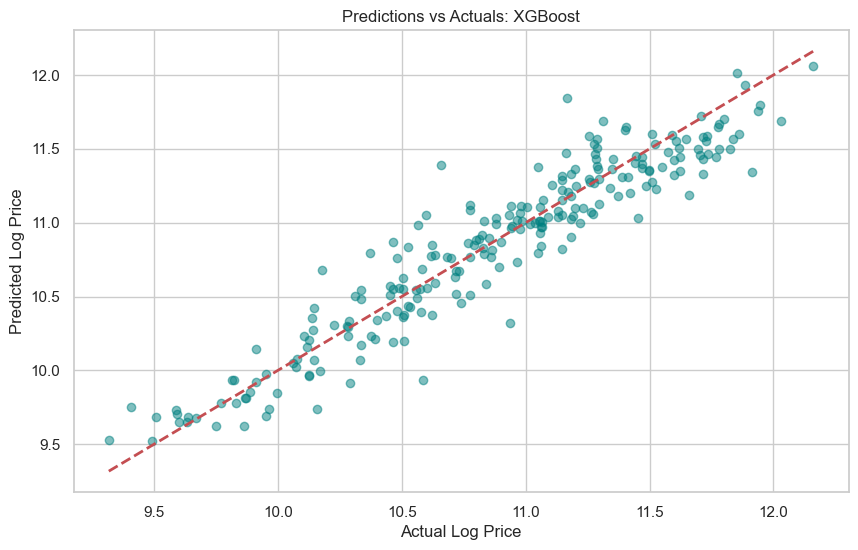

R² Score: 0.8914


In [70]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title(f"Predictions vs Actuals: {best_model_name}")
plt.show()

print(f"R² Score: {r2:.4f}")

## 4. Feature Importance

/var/folders/rb/rg8v17fx7nn0n6l9qg4rsgth0000gn/T/ipykernel_16725/1698310536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="rocket")


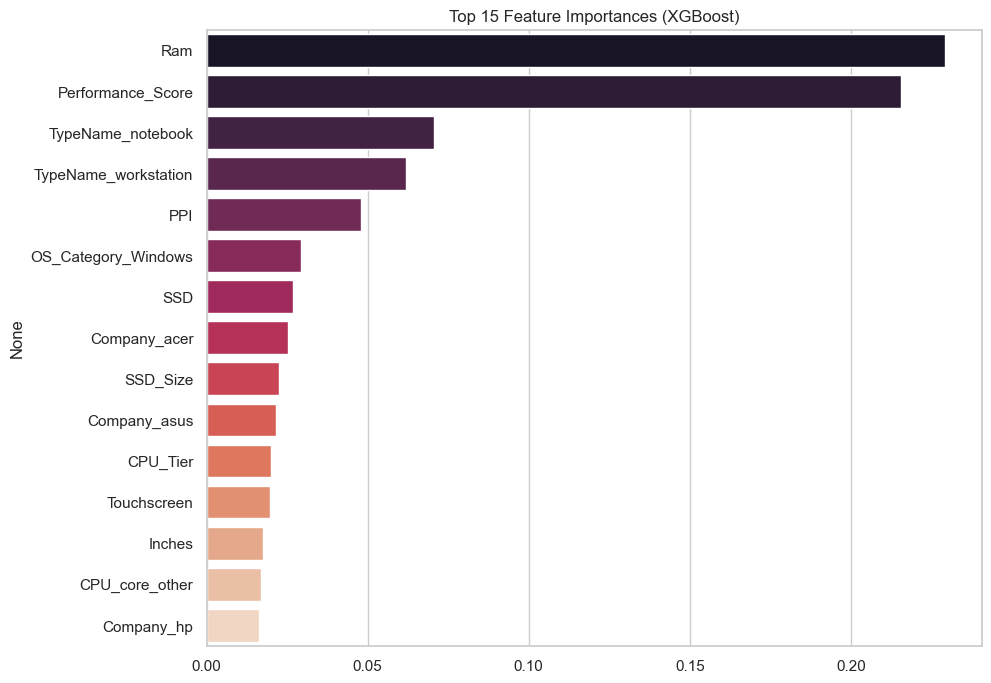

In [64]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="rocket")
    plt.title(f"Top 15 Feature Importances ({best_model_name})")
    plt.show()

## 5. Hyperparameter Tuning for Top 4 Models
Tuning top-performing models (XGBoost, Random Forest, SVR, Gradient Boosting) using RandomizedSearchCV to find the best configuration for each. RandomizedSearchCV used over GridSearchCV as the gain from an exhaustive Grid Search is usually negligible compared to the time saved by a random search. 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Random Forest Grid
rf_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 40, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# SVR Grid
svr_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

# Gradient Boosting Grid
gb_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}
# XGBoost Grid
xgb_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

In [68]:
def tune_model(estimator, param_dist, name):
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=estimator, 
        param_distributions=param_dist, 
        n_iter=15, 
        cv=5, 
        scoring='r2', 
        n_jobs=-1, 
        random_state=42
    )
    search.fit(X_train, y_train)
    print(f"Best {name} R2: {search.best_score_:.4f}")
    return search.best_estimator_

best_rf = tune_model(RandomForestRegressor(random_state=42), rf_grid, "Random Forest")
best_svr = tune_model(SVR(kernel='rbf'), svr_grid, "SVR")
best_gb = tune_model(GradientBoostingRegressor(random_state=42), gb_grid, "Gradient Boosting")
best_xgb = tune_model(XGBRegressor(random_state=42), xgb_grid, "XGBoost")

Tuning Random Forest...
Best Random Forest R2: 0.8839
Tuning SVR...
Best SVR R2: 0.8561
Tuning Gradient Boosting...
Best Gradient Boosting R2: 0.8962
Tuning XGBoost...
Best XGBoost R2: 0.8896


## 6. Final Evaluation and Comparison

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

def evaluate_final(model, name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    n, p = X_test.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mae_price = mean_absolute_error(np.exp(y_test), np.exp(y_pred))
    return {"Model": name, "R2": r2, "Adj R2": adj_r2, "MAE (Price)": mae_price}

final_results = [
    evaluate_final(best_rf, "Tuned Random Forest"),
    evaluate_final(best_svr, "Tuned SVR"),
    evaluate_final(best_gb, "Tuned Gradient Boosting"),
    evaluate_final(best_xgb, "Tuned XGBoost")
]

final_df = pd.DataFrame(final_results).sort_values(by="R2", ascending=False)
final_df.to_csv("../results/tuned_model_performance.csv", index=False)

# Save the best model
best_overall_name = final_df.iloc[0]["Model"]
best_overall_model = None
if "Random Forest" in best_overall_name: best_overall_model = best_rf
elif "SVR" in best_overall_name: best_overall_model = best_svr
elif "Gradient Boosting" in best_overall_name: best_overall_model = best_gb

if best_overall_model:
    os.makedirs("../models", exist_ok=True)
    joblib.dump(best_overall_model, "../models/best_laptop_price_model_final.joblib")
    print(f"Saved best model ({best_overall_name}) to ../models/best_laptop_price_model_final.joblib")

final_df

Saved best model (Tuned Gradient Boosting) to ../models/best_laptop_price_model_final.joblib


,Model,R2,Adj R2,MAE (Price)
2,Tuned Gradient Boosting,0.899320,0.873338,9900.315259
0,Tuned Random Forest,0.895143,0.868083,9887.318517
3,Tuned XGBoost,0.894244,0.866952,9894.836505
1,Tuned SVR,0.883369,0.853271,10747.492618


It can be seen that Gradient Boosting outperformed XGBoost after hyperparameter tuning. XGBoost is designed to already have default parameters quite optimized, which is why it was the best model prior to tuning. Gradient Boosting is very sensitive to learning rate and subsampling, so in the baseline it was likely taking steps that were too large or looking at too much data at once. During tuning, it found the optimal learning rate and depth that allowed it to learn the nuances of features more precisely than XGBoost. Additionally, XGBoost is built for big datasets as its complex internal regularization is designed to prevent overfitting. However, because this dataset is small, the extra complexity might have been a hindrance. It's possible that the 15 iterations found a near-perfect configuration for Gradient Boosting, whereas XGBoost has so many more "moving parts" (gamma, colsample_bytree, alpha, etc.) that 15 iterations only scratched the surface of its potential. It can also be seen that MAE is slightly higher for Gradient Boosting compared to Random Forest and XGBoost. MSE (and thus R^2) penalizes large errors much more severely than small because it squares them. Gradient Boosting minimizes this squared error, thus its R^2 improves. Meanwhile, Random Forest might have a few more "big misses", but it is more accurate on average for the most common laptops in the dataset (middle-range), which gives it a slightly better MAE. In conclusion, Gradient Boosting is the best overall model, but Random Forest is the best model for predicting typical, average-priced laptops. 

## 7. Visualizing Best Model Fit (Tuned Gradient Boosting)

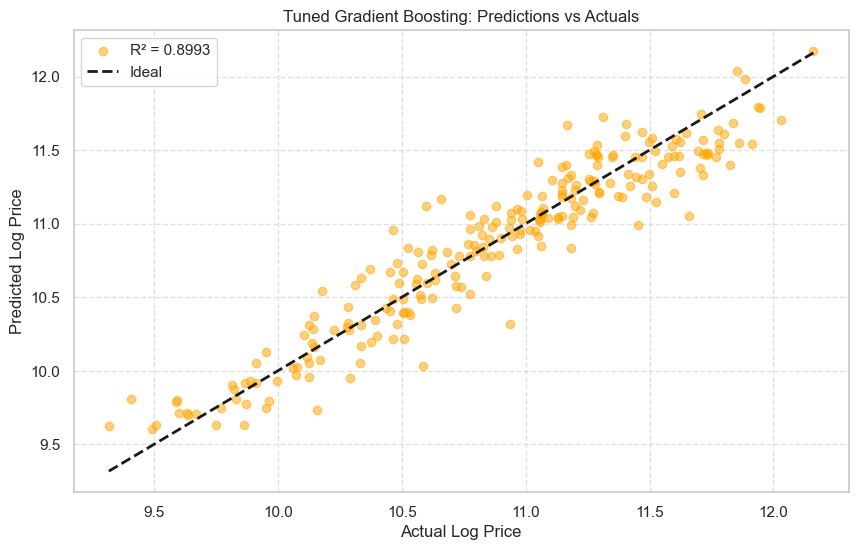

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

y_pred_tuned = best_gb.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.5, color='orange', label=f'R² = {r2_tuned:.4f}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Tuned Gradient Boosting: Predictions vs Actuals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()